# Exp6 - Notebook B: NDCLD15 TDA Feature Extraction

**Experiment:** Single-sensor contact-lens presentation attack detection on NDCLD15.

This is Notebook B of the 5-notebook NDCLD15 pipeline (A: multi-backbone
baseline - done, **B: TDA extraction - this notebook**, C: CNN+TDA fusion,
D: GradCAM+SHAP, E: comparison report).

This notebook re-derives the exact same train/val/test split Notebook A
used (same seed, same stratification logic), and extracts rich TDA
features from every image in that split. No new splitting decision is made
here - it reuses Notebook A's `split_definition.csv` only as a sanity
cross-check.

### Pipeline (per image)

```
Iris image
    |
Resize 64x64 + CLAHE contrast enhancement
    |
Threshold -> bright-pixel point cloud (up to 200 points)
    |
Vietoris-Rips persistent homology, H0 + H1 + H2
    |
Four feature groups per sample:
    - Raw persistence diagram statistics (count/mean/max lifetime per dim)
    - Persistence Image  (20x20 grid x 3 homology dims = 1200 features)
    - Betti curve         (50 bins x 3 homology dims  =  150 features)
    - Amplitude metrics    (4 metrics x 3 homology dims =  12 features)
    |
~1365 raw features per image, saved as one row per image per split
```

### Two fixes carried over from the IIITD-CLI Notebook B

1. **The `heat` amplitude metric is excluded.** It can trigger an
   `ArrayMemoryError` inside giotto-tda's internal Gaussian-filter step on
   certain diagrams (observed during the IIITD-CLI run of this same
   pipeline). The remaining four amplitude metrics (bottleneck, Wasserstein,
   landscape, betti) still give a rich multi-metric signal without that
   instability.
2. **Parallel extraction uses `n_jobs=4`, not `n_jobs=-1`.** Using every
   CPU core at once for this memory-heavy computation increases the risk of
   running out of RAM; 4 workers is a safer default that still gives a
   meaningful speedup over a single-process loop.

### Library fallback strategy

Same three-tier fallback as the IIITD-CLI Notebook B: **giotto-tda**
(richest, H0+H1+H2) -> **ripser** (H0+H1 only) -> pure-NumPy (H0 only,
slow). The notebook always produces an output regardless of which TDA
library is installed.

### Output

```
Experiments/Exp6_NDCLD15_MultiBackbone/outputs/
    tda_features/
        train_tda.csv
        val_tda.csv
        test_tda.csv
        tda_extraction_log.csv
```


## 1. Imports + TDA Backend Detection


In [1]:
# ---------------------------------------------------------------------------
# Standard imports, plus the same backend-detection block used in the
# IIITD-CLI TDA notebook - picks the richest available TDA library without
# crashing if a package is missing.
# ---------------------------------------------------------------------------
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from pathlib import Path
from tqdm import tqdm

warnings.filterwarnings('ignore')
np.random.seed(42)

TDA_BACKEND = None

try:
    from gtda.homology import VietorisRipsPersistence
    from gtda.diagrams import PersistenceImage, BettiCurve, Amplitude
    TDA_BACKEND = 'giotto-tda'
except ImportError:
    pass

if TDA_BACKEND is None:
    try:
        from ripser import ripser
        TDA_BACKEND = 'ripser'
    except ImportError:
        pass

if TDA_BACKEND is None:
    TDA_BACKEND = 'numpy-fallback'

print(f'TDA backend selected: {TDA_BACKEND}')
if TDA_BACKEND == 'giotto-tda':
    print('  -> Full feature set: H0+H1+H2, Persistence Image, Betti curve, Amplitude (~1365 features)')
elif TDA_BACKEND == 'ripser':
    print('  -> Reduced feature set: H0+H1 only (H2 skipped), Betti curve + Amplitude (~900 features)')
else:
    print('  -> Minimal feature set: H0+H1 only, slow pure-NumPy filtration (~900 features)')
    print('  -> Install giotto-tda for the full feature set: pip install giotto-tda')


TDA backend selected: giotto-tda
  -> Full feature set: H0+H1+H2, Persistence Image, Betti curve, Amplitude (~1365 features)


## 2. Config + Re-derive Notebook A's Split

Same seed, same stratified-split logic as Notebook A's Section 4 - this
reproduces the identical train/val/test image lists without needing to
re-save or re-load anything from Notebook A beyond the sanity-check CSV.


In [2]:
# ---------------------------------------------------------------------------
# Re-build the exact same (path, label) list and the exact same 70/15/15
# stratified split as Notebook A, using the same seed and same logic.
# ---------------------------------------------------------------------------
from sklearn.model_selection import train_test_split
from collections import Counter

PROJECT_ROOT = Path(r"C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD")
NDCLD_DIR = PROJECT_ROOT / 'Data' / 'Raw' / 'NDCLD15'
NDCLD_CSV = NDCLD_DIR / 'NDCLD15-with-Segmentation.csv'

EXP_NAME    = 'Exp6_NDCLD15_MultiBackbone'
EXP_DIR     = PROJECT_ROOT / 'Experiments' / EXP_NAME
TDA_DIR     = EXP_DIR / 'outputs' / 'tda_features'
TDA_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
VALID_EXTS = {'.tiff', '.tif', '.jpg', '.jpeg', '.png', '.bmp'}

df = pd.read_csv(NDCLD_CSV)
image_lookup = {
    Path(f).stem: str(NDCLD_DIR / f)
    for f in os.listdir(str(NDCLD_DIR)) if Path(f).suffix.lower() in VALID_EXTS
}

live_rows  = df[df['contacts'] == 'No']
spoof_rows = df[df['contacts'] == 'Yes']

all_data = []
for _, row in live_rows.iterrows():
    seq = str(row['sequenceid']).strip()
    if seq in image_lookup:
        all_data.append((image_lookup[seq], 0))
for _, row in spoof_rows.iterrows():
    seq = str(row['sequenceid']).strip()
    if seq in image_lookup:
        all_data.append((image_lookup[seq], 1))

all_labels_list = [l for _, l in all_data]
train_data, temp_data = train_test_split(
    all_data, test_size=0.30, stratify=all_labels_list, random_state=SEED, shuffle=True
)
temp_labels = [l for _, l in temp_data]
val_data, test_data = train_test_split(
    temp_data, test_size=0.50, stratify=temp_labels, random_state=SEED, shuffle=True
)

splits = {'train': train_data, 'val': val_data, 'test': test_data}

# Cross-check against Notebook A's saved split sizes, if available.
split_def_path = EXP_DIR / 'outputs' / 'metrics' / 'split_definition.csv'
if split_def_path.exists():
    nb_a_split = pd.read_csv(split_def_path)
    print('Cross-check against Notebook A split_definition.csv:')
    for _, row in nb_a_split.iterrows():
        split_name = row['Split'].lower()
        match = len(splits[split_name]) == row['N']
        status = '\u2713' if match else '\u26a0\ufe0f MISMATCH'
        print(f"  {row['Split']:6s}: {len(splits[split_name])} (expected {row['N']}) {status}")
else:
    print('split_definition.csv not found - proceeding without cross-check.')

for name, data in splits.items():
    c = Counter(l for _, l in data)
    print(f'  {name:6s}: {len(data):5d} | Live:{c[0]:5d} | Spoof:{c[1]:5d}')

# Point cloud / TDA extraction config.
TDA_CONFIG = {
    'img_size_pc':   64,
    'threshold':     127,
    'max_points':    100,   # kept at 100 (not 200) for extraction speed
    'min_points':    10,
    'homology_dims': [0, 1, 2] if TDA_BACKEND == 'giotto-tda' else [0, 1],
    'pi_n_bins':     20,
    'betti_n_bins':  50,
}
print(f'\nHomology dimensions to compute: {TDA_CONFIG["homology_dims"]}')


Cross-check against Notebook A split_definition.csv:
  Train : 5110 (expected 5110) ✓
  Val   : 1095 (expected 1095) ✓
  Test  : 1095 (expected 1095) ✓
  train :  5110 | Live: 1733 | Spoof: 3377
  val   :  1095 | Live:  371 | Spoof:  724
  test  :  1095 | Live:  371 | Spoof:  724

Homology dimensions to compute: [0, 1, 2]


## 3. Point Cloud Extraction (with CLAHE)


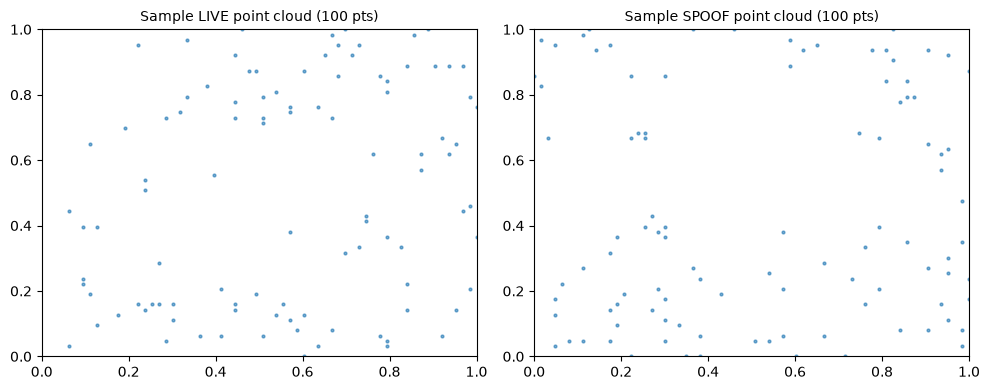

Point cloud extraction function ready ✓


In [3]:
# ---------------------------------------------------------------------------
# image_to_point_cloud(): resize -> CLAHE -> threshold -> normalized,
# fixed-size point cloud. Identical to the IIITD-CLI version.
# ---------------------------------------------------------------------------
def image_to_point_cloud(img_path, config):
    sz, thresh = config['img_size_pc'], config['threshold']
    max_pts, min_pts = config['max_points'], config['min_points']

    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        try:
            from PIL import Image as PILImage
            img = np.array(PILImage.open(img_path).convert('L'))
        except Exception:
            return np.zeros((max_pts, 2), dtype=np.float32)

    img = cv2.resize(img, (sz, sz), interpolation=cv2.INTER_AREA)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img = clahe.apply(img)

    rows, cols = np.where(img > thresh)
    if len(rows) < min_pts:
        rows, cols = np.where(img > thresh // 2)
    if len(rows) < min_pts // 2:
        return np.zeros((max_pts, 2), dtype=np.float32)

    points = np.column_stack([rows, cols]).astype(np.float32) / (sz - 1)
    if len(points) > max_pts:
        idx = np.random.choice(len(points), max_pts, replace=False)
        points = points[idx]
    elif len(points) < max_pts:
        pad = np.zeros((max_pts - len(points), 2), dtype=np.float32)
        points = np.vstack([points, pad])
    return points

# Visual sanity check on one Live and one Spoof image.
sample_live  = next(p for p, l in train_data if l == 0)
sample_spoof = next(p for p, l in train_data if l == 1)
pc_live  = image_to_point_cloud(sample_live,  TDA_CONFIG)
pc_spoof = image_to_point_cloud(sample_spoof, TDA_CONFIG)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, pc, title in [(axes[0], pc_live,  'Sample LIVE point cloud'),
                       (axes[1], pc_spoof, 'Sample SPOOF point cloud')]:
    valid = pc[pc.sum(1) > 0]
    ax.scatter(valid[:, 1], 1 - valid[:, 0], s=4, alpha=0.6)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_title(f'{title} ({len(valid)} pts)', fontsize=10)
plt.tight_layout()
plt.show()
print('Point cloud extraction function ready \u2713')


## 4. Persistent Homology + Multi-Descriptor Feature Extraction

Same backend-agnostic interface as the IIITD-CLI Notebook B, with the
`heat` amplitude metric removed to avoid the memory crash seen previously.


In [4]:
# ---------------------------------------------------------------------------
# extract_tda_features(): point cloud -> persistence diagram -> feature dict.
# Three implementations behind one interface, selected by TDA_BACKEND.
# ---------------------------------------------------------------------------
HOMOLOGY_DIMS = TDA_CONFIG['homology_dims']
PI_BINS       = TDA_CONFIG['pi_n_bins']
BETTI_BINS    = TDA_CONFIG['betti_n_bins']

if TDA_BACKEND == 'giotto-tda':
    _vr = VietorisRipsPersistence(homology_dimensions=HOMOLOGY_DIMS, n_jobs=1)
    _pi = PersistenceImage(n_bins=PI_BINS, sigma=0.1)
    _bc = BettiCurve(n_bins=BETTI_BINS)
    # NOTE: 'heat' metric excluded - it can build a dense Gaussian-filtered
    # image grid that blows up to tens of millions of elements depending on
    # the diagram's value range, causing an ArrayMemoryError (seen in
    # practice on the IIITD-CLI run of this same pipeline). The remaining
    # four metrics still give a rich multi-metric amplitude signal.
    _amp_metrics = ['bottleneck', 'wasserstein', 'landscape', 'betti']
    _amps = {m: Amplitude(metric=m) for m in _amp_metrics}

def _diagram_to_simple_features(dgm_by_dim, max_edge=1.0):
    feats = {}
    for dim in HOMOLOGY_DIMS:
        bars = dgm_by_dim.get(dim, np.zeros((0, 2)))
        if len(bars) == 0:
            feats[f'h{dim}_count'] = 0
            feats[f'h{dim}_mean_life'] = 0.0
            feats[f'h{dim}_max_life'] = 0.0
            continue
        life = np.clip(bars[:, 1] - bars[:, 0], 0, max_edge)
        feats[f'h{dim}_count']     = len(bars)
        feats[f'h{dim}_mean_life'] = float(life.mean())
        feats[f'h{dim}_max_life']  = float(life.max())
    return feats

def extract_tda_features_giotto(point_cloud):
    valid = point_cloud[point_cloud.sum(1) > 0]
    if len(valid) < 3:
        return None
    diagrams = _vr.fit_transform(valid[None, :, :])
    pi_feats  = _pi.fit_transform(diagrams).reshape(-1)
    bc_feats  = _bc.fit_transform(diagrams).reshape(-1)
    amp_feats = []
    for m in _amp_metrics:
        amp_feats.append(_amps[m].fit_transform(diagrams).reshape(-1))
    amp_feats = np.concatenate(amp_feats)

    dgm_by_dim = {}
    for dim in HOMOLOGY_DIMS:
        mask = diagrams[0, :, 2] == dim
        dgm_by_dim[dim] = diagrams[0, mask][:, :2]
    simple_feats = _diagram_to_simple_features(dgm_by_dim)

    return {'pi': pi_feats, 'bc': bc_feats, 'amp': amp_feats, 'simple': simple_feats}

def extract_tda_features_ripser(point_cloud):
    valid = point_cloud[point_cloud.sum(1) > 0]
    if len(valid) < 3:
        return None
    result = ripser(valid, maxdim=1)
    dgm_by_dim = {0: result['dgms'][0], 1: result['dgms'][1]}
    simple_feats = _diagram_to_simple_features(dgm_by_dim)

    bc_feats = []
    for dim in HOMOLOGY_DIMS:
        bars = dgm_by_dim.get(dim, np.zeros((0, 2)))
        bars = bars[np.isfinite(bars[:, 1])] if len(bars) else bars
        eps_grid = np.linspace(0, 1.0, BETTI_BINS)
        curve = np.array([np.sum((bars[:, 0] <= e) & (bars[:, 1] > e)) for e in eps_grid]) if len(bars) else np.zeros(BETTI_BINS)
        bc_feats.append(curve)
    bc_feats = np.concatenate(bc_feats)

    amp_feats = []
    for dim in HOMOLOGY_DIMS:
        bars = dgm_by_dim.get(dim, np.zeros((0, 2)))
        bars = bars[np.isfinite(bars[:, 1])] if len(bars) else bars
        life = (bars[:, 1] - bars[:, 0]) if len(bars) else np.zeros(1)
        amp_feats.extend([float(np.sum(life)), float(np.sqrt(np.sum(life**2)))])
    amp_feats = np.array(amp_feats)

    pi_feats = []
    for dim in HOMOLOGY_DIMS:
        bars = dgm_by_dim.get(dim, np.zeros((0, 2)))
        bars = bars[np.isfinite(bars[:, 1])] if len(bars) else bars
        if len(bars) == 0:
            pi_feats.append(np.zeros(PI_BINS * PI_BINS))
            continue
        hist, _, _ = np.histogram2d(bars[:, 0], bars[:, 1], bins=PI_BINS, range=[[0, 1], [0, 1]])
        pi_feats.append(hist.flatten())
    pi_feats = np.concatenate(pi_feats)

    return {'pi': pi_feats, 'bc': bc_feats, 'amp': amp_feats, 'simple': simple_feats}

def extract_tda_features_numpy(point_cloud):
    valid = point_cloud[point_cloud.sum(1) > 0]
    if len(valid) < 3:
        return None
    from scipy.spatial.distance import pdist, squareform
    dists = pdist(valid)
    thresholds = np.linspace(0, dists.max() if len(dists) else 1.0, BETTI_BINS)
    n = len(valid)
    bc0 = []
    for t in thresholds:
        parent = list(range(n))
        def find(x):
            while parent[x] != x:
                x = parent[x]
            return x
        D = squareform(dists)
        for i in range(n):
            for j in range(i+1, n):
                if D[i, j] <= t:
                    ri, rj = find(i), find(j)
                    if ri != rj:
                        parent[ri] = rj
        n_components = len(set(find(i) for i in range(n)))
        bc0.append(n_components)
    bc_feats = np.concatenate([np.array(bc0), np.zeros(BETTI_BINS)])
    simple_feats = {'h0_count': n, 'h0_mean_life': 0.0, 'h0_max_life': float(dists.max() if len(dists) else 0),
                     'h1_count': 0, 'h1_mean_life': 0.0, 'h1_max_life': 0.0}
    pi_feats  = np.zeros(PI_BINS * PI_BINS * 2)
    amp_feats = np.array([float(dists.mean() if len(dists) else 0), float(dists.std() if len(dists) else 0)])
    return {'pi': pi_feats, 'bc': bc_feats, 'amp': amp_feats, 'simple': simple_feats}

_extractors = {
    'giotto-tda':     extract_tda_features_giotto,
    'ripser':         extract_tda_features_ripser,
    'numpy-fallback': extract_tda_features_numpy,
}
extract_tda_features = _extractors[TDA_BACKEND]

test_result = extract_tda_features(pc_live)
if test_result is not None:
    n_feat = len(test_result['pi']) + len(test_result['bc']) + len(test_result['amp']) + len(test_result['simple'])
    print(f'Feature extraction test OK - {n_feat} raw features per image '
          f'(PI:{len(test_result["pi"])}, Betti:{len(test_result["bc"])}, '
          f'Amplitude:{len(test_result["amp"])}, Simple:{len(test_result["simple"])})')
else:
    print('Feature extraction returned None on test sample - check point cloud quality.')


Feature extraction test OK - 1371 raw features per image (PI:1200, Betti:150, Amplitude:12, Simple:9)


## 5. Generate + Save TDA Features for Train / Val / Test (Parallel)

Uses `n_jobs=4` rather than `n_jobs=-1` - fewer simultaneous heavy
amplitude computations reduces peak memory pressure, which previously
caused a crash on the IIITD-CLI run of this same step.


In [5]:
# ---------------------------------------------------------------------------
# generate_tda_for_split(): runs the full point-cloud -> homology -> feature
# pipeline over every image in one split, in parallel with n_jobs=4.
# ---------------------------------------------------------------------------
from joblib import Parallel, delayed

def process_one_image(item, config):
    path, label = item
    pc = image_to_point_cloud(path, config)
    feats = extract_tda_features(pc)
    if feats is None:
        return None
    rec = {'path': path, 'label': label}
    for i, v in enumerate(feats['pi']):  rec[f'pi_{i}']  = v
    for i, v in enumerate(feats['bc']):  rec[f'bc_{i}']  = v
    for i, v in enumerate(feats['amp']): rec[f'amp_{i}'] = v
    rec.update(feats['simple'])
    return rec

def generate_tda_for_split(data, split_name, config):
    print(f'  {split_name} starting ({len(data)} images, parallel, n_jobs=4)...')
    results = Parallel(n_jobs=4, prefer='processes')(
        delayed(process_one_image)(item, config) for item in data
    )
    records = [r for r in results if r is not None]
    failed = len(data) - len(records)
    out_df = pd.DataFrame(records)
    out_path = TDA_DIR / f'{split_name}_tda.csv'
    out_df.to_csv(out_path, index=False)
    print(f'  {split_name:6s}: {len(out_df):5d} saved | {failed:3d} failed -> {out_path.name}')
    return len(out_df), len(out_df.columns) - 2  # exclude path/label from feature count

print(f'Generating TDA features for train/val/test (backend: {TDA_BACKEND}, parallel)')
print('This will take a while depending on dataset size and backend speed.\n')

extraction_log = []
for split_name, data in splits.items():
    n_saved, n_feats = generate_tda_for_split(data, split_name, TDA_CONFIG)
    extraction_log.append({'Split': split_name, 'N': n_saved, 'Features': n_feats})

log_df = pd.DataFrame(extraction_log)
log_df.to_csv(TDA_DIR / 'tda_extraction_log.csv', index=False)
print('\nExtraction log:')
print(log_df.to_string(index=False))


Generating TDA features for train/val/test (backend: giotto-tda, parallel)
This will take a while depending on dataset size and backend speed.

  train starting (5110 images, parallel, n_jobs=4)...
  train :  5110 saved |   0 failed -> train_tda.csv
  val starting (1095 images, parallel, n_jobs=4)...
  val   :  1095 saved |   0 failed -> val_tda.csv
  test starting (1095 images, parallel, n_jobs=4)...
  test  :  1095 saved |   0 failed -> test_tda.csv

Extraction log:
Split    N  Features
train 5110      1371
  val 1095      1371
 test 1095      1371


## 6. Verify Saved Features + Quick Live vs Spoof Comparison


In [6]:
# ---------------------------------------------------------------------------
# Reload the train TDA CSV, print shape, and compare simple H0/H1 lifetime
# statistics between Live and Spoof - a quick, cheap signal check before
# Notebook C does the real feature selection and fusion training.
# ---------------------------------------------------------------------------
train_tda_path = TDA_DIR / 'train_tda.csv'
if train_tda_path.exists():
    tda_df = pd.read_csv(train_tda_path)
    feature_cols = [c for c in tda_df.columns if c not in ('path', 'label')]
    print(f'train_tda.csv: {tda_df.shape[0]} rows x {len(feature_cols)} features')

    if 'h0_mean_life' in tda_df.columns and 'h1_mean_life' in tda_df.columns:
        live_h0  = tda_df[tda_df.label == 0]['h0_mean_life'].mean()
        spoof_h0 = tda_df[tda_df.label == 1]['h0_mean_life'].mean()
        live_h1  = tda_df[tda_df.label == 0]['h1_mean_life'].mean()
        spoof_h1 = tda_df[tda_df.label == 1]['h1_mean_life'].mean()
        print(f'  H0 mean lifetime - Live: {live_h0:.4f}  Spoof: {spoof_h0:.4f}  (diff: {abs(live_h0-spoof_h0):.4f})')
        print(f'  H1 mean lifetime - Live: {live_h1:.4f}  Spoof: {spoof_h1:.4f}  (diff: {abs(live_h1-spoof_h1):.4f})')


train_tda.csv: 5110 rows x 1371 features
  H0 mean lifetime - Live: 0.0641  Spoof: 0.0643  (diff: 0.0001)
  H1 mean lifetime - Live: 0.0328  Spoof: 0.0330  (diff: 0.0002)


## 7. Done


In [8]:
# ---------------------------------------------------------------------------
# Final summary and pointer to Notebook C.
# ---------------------------------------------------------------------------

print(f'  Backend used     : {TDA_BACKEND}')
print(f'  Homology dims    : {HOMOLOGY_DIMS}')
print(f'  Files saved      : {len(list(TDA_DIR.glob("*_tda.csv")))} CSVs in {TDA_DIR}')
print(log_df.to_string(index=False))



  Backend used     : giotto-tda
  Homology dims    : [0, 1, 2]
  Files saved      : 3 CSVs in C:\Users\sahar\OneDrive\Desktop\EXPLAINABLE_IRIS_PAD\Experiments\Exp6_NDCLD15_MultiBackbone\outputs\tda_features
Split    N  Features
train 5110      1371
  val 1095      1371
 test 1095      1371
